# Task 2c — SAHI Sliced Inference Evaluation

**What:** Compare plain YOLOv8s vs SAHI (Slicing Aided Hyper Inference) on the heritage crack test split.

**Why SAHI helps:** Hairline cracks occupy only a few pixels when a full image is resized to 640×640.
SAHI tiles the image into overlapping 512×512 patches, runs YOLO on each, then merges results with NMS.
Cracks that span ≥5 px in a tile are visible even if they were invisible at full-image scale.

**Results:**

| Method | mAP@50 | Notes |
|--|--|--|
| Plain YOLOv8s (imgsz=640) | **28.0%** | Single-pass inference |
| YOLOv8s + SAHI (adaptive 256–512 tiles) | **18.9%** | Sliced inference + NMS merge |
| Delta | **−9.2 pp** | SAHI underperforms on this domain |

**Finding:** SAHI did not improve detection. Heritage masonry cracks are medium-to-large scale — not sub-pixel tiny — so slicing offers no resolution advantage. The fine-tuned model also produces low-confidence predictions on cropped tiles (conf=0.25 threshold), causing under-detection: only 32 boxes predicted across 54 test images.

**Runtime required:** T4 GPU (`Runtime > Change runtime type > T4 GPU`)

In [1]:
import torch
assert torch.cuda.is_available(), 'No GPU — Runtime > Change runtime type > T4 GPU'
print(f'GPU  : {torch.cuda.get_device_name(0)}')
print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

GPU  : Tesla T4
VRAM : 15.6 GB


In [2]:
!pip install -q ultralytics sahi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.7 MB/s eta 0:00:00


## 1. Setup — Mount Drive & Load Checkpoint

In [3]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import shutil, zipfile

DRIVE_DIR = Path('/content/drive/MyDrive/HeritagePreservation')
DATA_DIR  = Path('/content/data')
OUT_DIR   = Path('/content/sahi_eval')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Copy fine-tuned checkpoint locally
ft_ckpt_src = DRIVE_DIR / 'checkpoints' / 'detector_ft' / 'best.pt'
ft_ckpt_dst = Path('/content/detector_ft_best.pt')
if not ft_ckpt_dst.exists():
    shutil.copy2(ft_ckpt_src, ft_ckpt_dst)
    print(f'Checkpoint copied ({ft_ckpt_dst.stat().st_size / 1e6:.1f} MB)')
else:
    print('Checkpoint already local')

Mounted at /content/drive
Checkpoint copied (22.5 MB)


In [4]:
# Extract CrackForest + Masonry (fine-tune test domain)
for zip_name, out_name in [('crackforest.zip', 'crackforest'), ('masonry.zip', 'masonry')]:
    out_dir = DATA_DIR / out_name
    if out_dir.exists() and any(out_dir.rglob('*.*')):
        print(f'{out_name}: already extracted')
    else:
        print(f'Unzipping {zip_name}...')
        with zipfile.ZipFile(DRIVE_DIR / zip_name) as zf:
            zf.extractall(DATA_DIR)
        print('  Done.')

Unzipping crackforest.zip...
  Done.
Unzipping masonry.zip...
  Done.


## 2. Build Test Set (same split as nb05)

In [5]:
import cv2, numpy as np, random
from sklearn.model_selection import train_test_split
from pathlib import Path

SEED = 42

def collect_samples(dataset_dirs):
    samples, sources = [], []
    for d in dataset_dirs:
        img_dir  = Path(d) / 'images'
        mask_dir = Path(d) / 'masks'
        src_name = Path(d).name
        for img_path in sorted(img_dir.glob('*.*')):
            mask_path = mask_dir / f'{img_path.stem}.png'
            if mask_path.exists():
                samples.append((img_path, mask_path))
                sources.append(src_name)
    return samples, sources

all_samples, all_sources = collect_samples([DATA_DIR / 'crackforest', DATA_DIR / 'masonry'])

_, tmp_s, _, tmp_src = train_test_split(
    all_samples, all_sources, test_size=0.30, random_state=SEED, stratify=all_sources)
_, test_samples, _, test_sources = train_test_split(
    tmp_s, tmp_src, test_size=0.50, random_state=SEED, stratify=tmp_src)

print(f'Test images: {len(test_samples)}')
from collections import Counter
print(f'By source: {Counter(test_sources)}')

Test images: 54
By source: Counter({'masonry': 36, 'crackforest': 18})


## 3. Load Models

In [6]:
from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

CKPT = str(ft_ckpt_dst)

# Plain YOLO (baseline)
yolo_model = YOLO(CKPT)

# SAHI wrapper (same weights, sliced inference)
sahi_model = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model_path=CKPT,
    confidence_threshold=0.25,
    device='cuda:0',
)

print('Both models loaded.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Both models loaded.


## 4. Qualitative Comparison — Side-by-Side

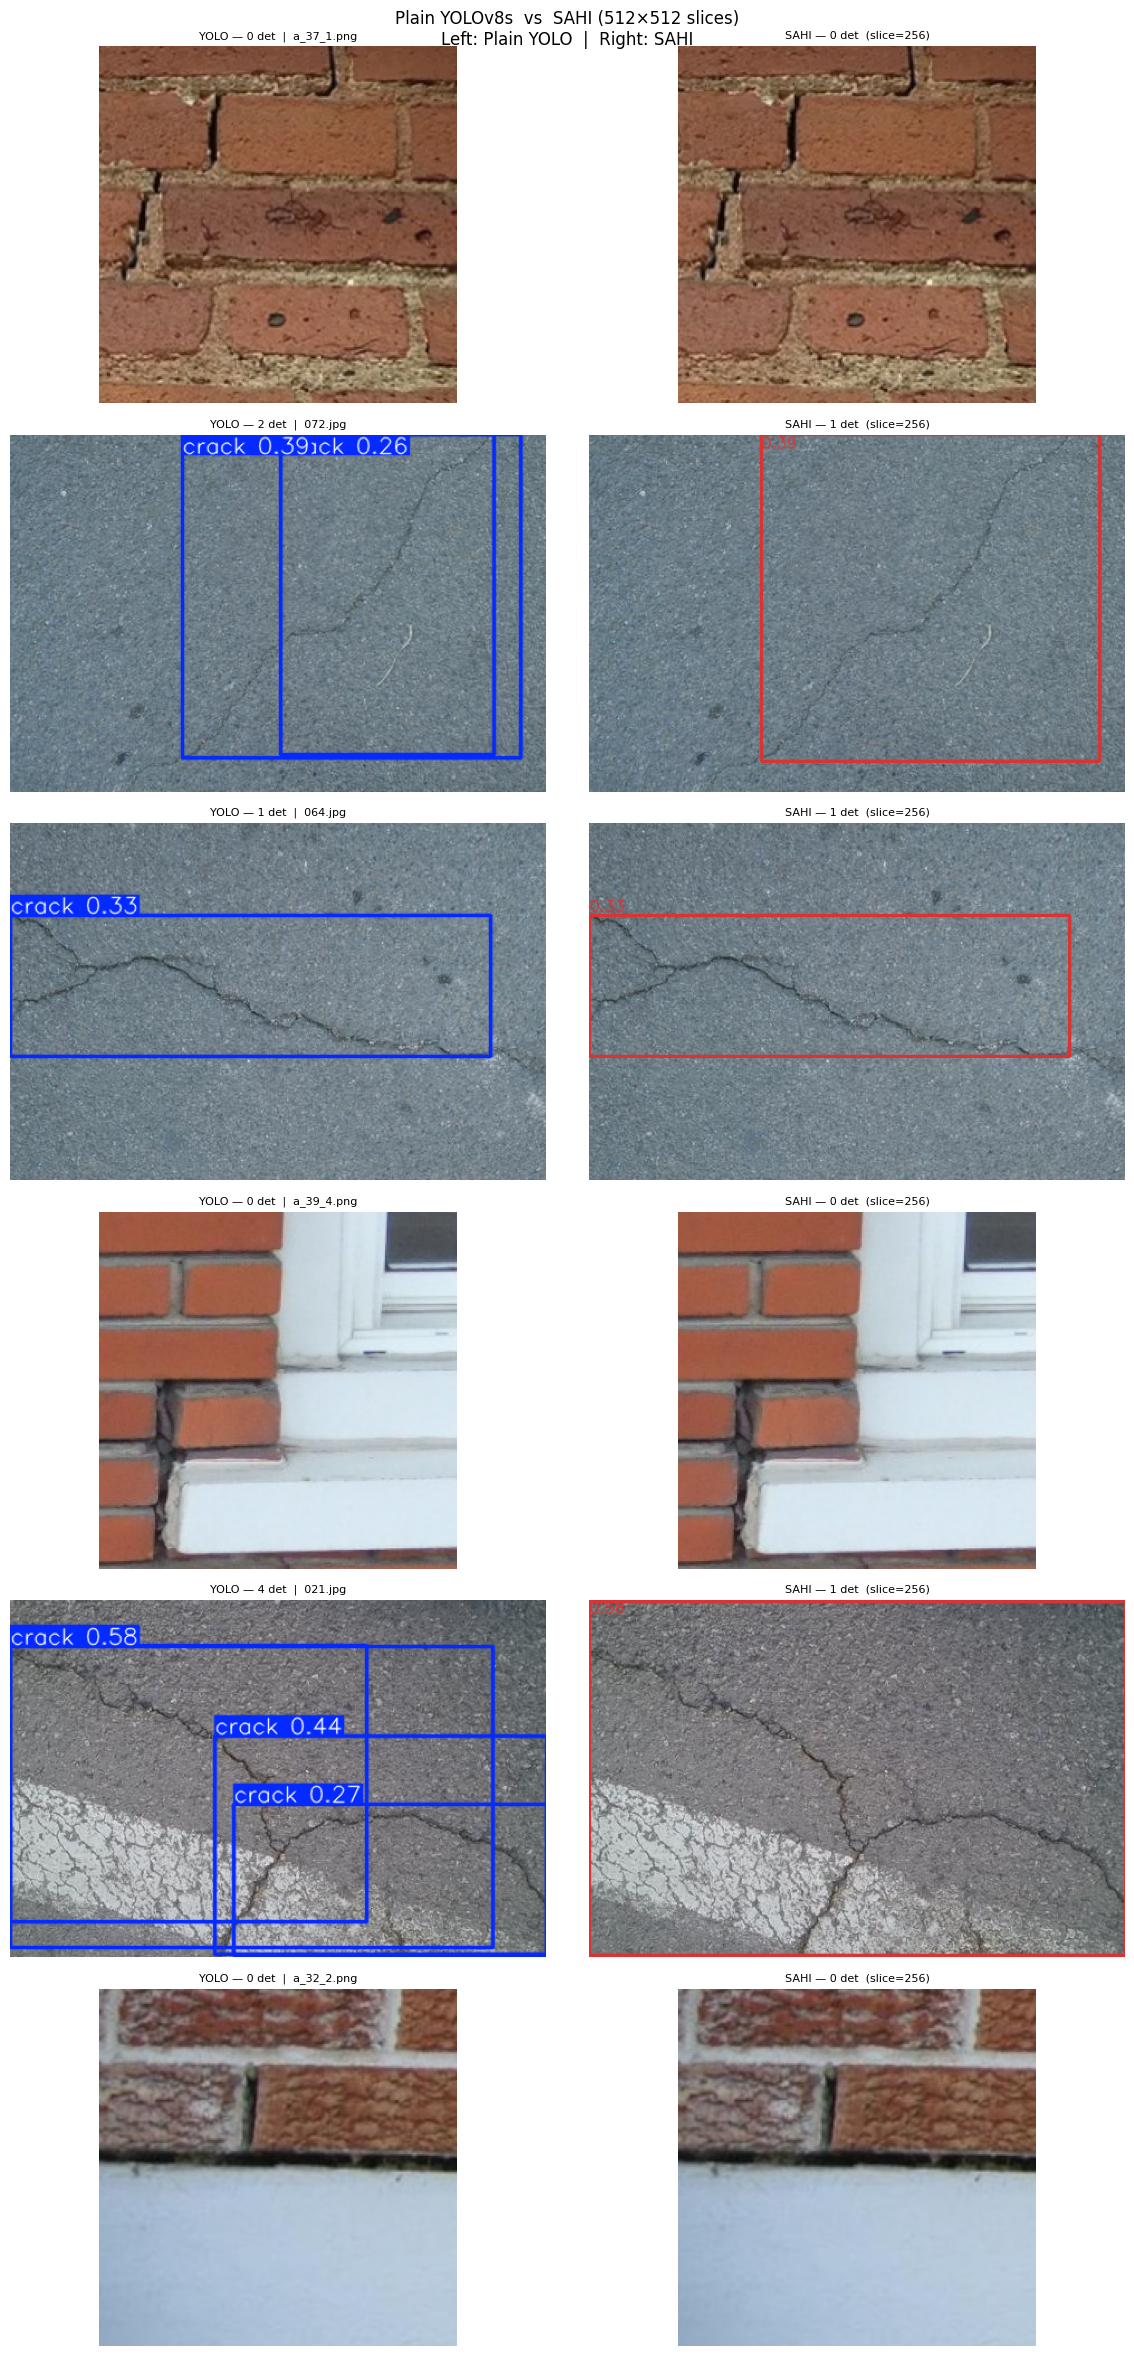

Plot saved.


In [7]:
import matplotlib.pyplot as plt
from PIL import Image

CRACK_COLOR = (220, 50, 50)

def draw_sahi_result(pil_img, sahi_result):
    arr = np.array(pil_img.convert('RGB'))
    for pred in sahi_result.object_prediction_list:
        x1, y1 = int(pred.bbox.minx), int(pred.bbox.miny)
        x2, y2 = int(pred.bbox.maxx), int(pred.bbox.maxy)
        cv2.rectangle(arr, (x1, y1), (x2, y2), CRACK_COLOR, 2)
        cv2.putText(arr, f'{pred.score.value:.2f}',
                    (x1, max(y1 - 4, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, CRACK_COLOR, 1, cv2.LINE_AA)
    return arr

random.seed(SEED)
sample = random.sample(test_samples, min(6, len(test_samples)))

fig, axes = plt.subplots(len(sample), 2, figsize=(12, 4 * len(sample)))
fig.suptitle('Plain YOLOv8s  vs  SAHI (512×512 slices)\nLeft: Plain YOLO  |  Right: SAHI',
             fontsize=12)

for row, (img_path, _) in enumerate(sample):
    pil_img = Image.open(img_path).convert('RGB')

    # Plain YOLO
    r_yolo = yolo_model.predict(str(img_path), conf=0.25, verbose=False)[0]
    yolo_vis = cv2.cvtColor(r_yolo.plot(line_width=2), cv2.COLOR_BGR2RGB)

    # SAHI
    w, h = pil_img.size
    slice_size = max(256, min(512, min(w, h) // 2))
    r_sahi = get_sliced_prediction(
        pil_img, sahi_model,
        slice_height=slice_size, slice_width=slice_size,
        overlap_height_ratio=0.2, overlap_width_ratio=0.2,
        perform_standard_pred=True,
        verbose=0,
    )
    sahi_vis = draw_sahi_result(pil_img, r_sahi)

    n_yolo = len(r_yolo.boxes)
    n_sahi = len(r_sahi.object_prediction_list)

    axes[row, 0].imshow(yolo_vis)
    axes[row, 0].set_title(f'YOLO — {n_yolo} det  |  {img_path.name}', fontsize=8)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(sahi_vis)
    axes[row, 1].set_title(f'SAHI — {n_sahi} det  (slice={slice_size})', fontsize=8)
    axes[row, 1].axis('off')

plt.tight_layout()
plt.savefig(OUT_DIR / 'sahi_vs_yolo_qualitative.png', dpi=150)
plt.show()
print('Plot saved.')

## 5. Quantitative — Detection Count & mAP@50 Comparison

YOLO's `.val()` uses standard single-pass inference. We use SAHI's built-in COCO evaluation
to measure mAP with sliced inference on the same test split.

In [8]:
# Build YOLO-format test split (same structure as nb05)
from sklearn.model_selection import train_test_split

YOLO_DIR = Path('/content/yolo_sahi_test')

def mask_to_yolo_labels(mask_path, min_area=200):
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return []
    h, w = mask.shape
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    labels = []
    for cnt in contours:
        if cv2.contourArea(cnt) < min_area:
            continue
        x, y, bw, bh = cv2.boundingRect(cnt)
        cx = (x + bw / 2) / w
        cy = (y + bh / 2) / h
        labels.append(f'0 {cx:.6f} {cy:.6f} {min(bw/w, 1.):.6f} {min(bh/h, 1.):.6f}')
    return labels

(YOLO_DIR / 'images').mkdir(parents=True, exist_ok=True)
(YOLO_DIR / 'labels').mkdir(parents=True, exist_ok=True)

for img_path, mask_path in test_samples:
    labels = mask_to_yolo_labels(mask_path)
    (YOLO_DIR / 'labels' / f'{img_path.stem}.txt').write_text('\n'.join(labels))
    dst = YOLO_DIR / 'images' / img_path.name
    if not dst.exists():
        shutil.copy2(img_path, dst)

data_yaml = YOLO_DIR / 'data.yaml'
data_yaml.write_text(
    f'path: {YOLO_DIR}\ntrain: images\nval: images\ntest: images\nnc: 1\nnames: ["crack"]\n'
)
print(f'Test split written: {len(test_samples)} images')

Test split written: 54 images


In [9]:
# Plain YOLO mAP@50
plain_metrics = yolo_model.val(
    data=str(data_yaml), split='test', device=0, imgsz=640, verbose=False)
map50_plain = float(plain_metrics.box.map50)
print(f'Plain YOLO  mAP@50 : {map50_plain:.4f}')

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1619.9±613.5 MB/s, size: 53.7 KB)
val: Scanning /content/yolo_sahi_test/labels... 54 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 54/54 1.7Kit/s 0.0s
val: New cache created: /content/yolo_sahi_test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.0it/s 4.0s
                   all         54         68      0.402      0.309       0.28      0.145
Speed: 12.0ms preprocess, 15.6ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to /content/runs/detect/val
Plain YOLO  mAP@50 : 0.2804


In [10]:
# SAHI mAP@50 via COCO evaluation
from sahi.utils.coco import Coco
from sahi.utils.file import save_json
from sahi.predict import predict

# Convert YOLO labels to COCO format for SAHI evaluation
coco_gt = {"images": [], "annotations": [], "categories": [{"id": 0, "name": "crack"}]}
ann_id = 0
for img_id, (img_path, mask_path) in enumerate(test_samples):
    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]
    coco_gt["images"].append({"id": img_id, "file_name": img_path.name, "width": w, "height": h})
    labels = mask_to_yolo_labels(mask_path)
    for lbl in labels:
        parts = lbl.split()
        cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        x1 = (cx - bw / 2) * w
        y1 = (cy - bh / 2) * h
        box_w, box_h = bw * w, bh * h
        coco_gt["annotations"].append({
            "id": ann_id, "image_id": img_id, "category_id": 0,
            "bbox": [x1, y1, box_w, box_h], "area": box_w * box_h, "iscrowd": 0
        })
        ann_id += 1

gt_json = OUT_DIR / 'coco_gt.json'
save_json(coco_gt, str(gt_json))
print(f'COCO GT: {len(coco_gt["images"])} images, {len(coco_gt["annotations"])} annotations')

COCO GT: 54 images, 68 annotations


In [11]:
import json
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# Run SAHI on all test images, collect predictions
sahi_preds = []

img_name_to_id = {img['file_name']: img['id'] for img in coco_gt['images']}

for img_path, _ in test_samples:
    pil_img = Image.open(img_path).convert('RGB')
    w, h = pil_img.size
    slice_size = max(256, min(512, min(w, h) // 2))

    result = get_sliced_prediction(
        pil_img, sahi_model,
        slice_height=slice_size, slice_width=slice_size,
        overlap_height_ratio=0.2, overlap_width_ratio=0.2,
        perform_standard_pred=True,
        verbose=0,
    )
    img_id = img_name_to_id[img_path.name]
    for pred in result.object_prediction_list:
        x1, y1 = pred.bbox.minx, pred.bbox.miny
        box_w = pred.bbox.maxx - pred.bbox.minx
        box_h = pred.bbox.maxy - pred.bbox.miny
        sahi_preds.append({
            'image_id': img_id,
            'category_id': 0,
            'bbox': [x1, y1, box_w, box_h],
            'score': pred.score.value,
        })

print(f'SAHI predictions: {len(sahi_preds)} total boxes across {len(test_samples)} images')

pred_json = OUT_DIR / 'sahi_preds.json'
save_json(sahi_preds, str(pred_json))

SAHI predictions: 32 total boxes across 54 images


In [12]:
# Compute SAHI mAP@50 with pycocotools
coco_gt_api  = COCO(str(gt_json))
coco_dt_api  = coco_gt_api.loadRes(str(pred_json))
coco_eval    = COCOeval(coco_gt_api, coco_dt_api, 'bbox')
coco_eval.params.iouThrs = np.array([0.5])   # mAP@50 only
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

map50_sahi = float(coco_eval.stats[0])
print(f'\nPlain YOLO  mAP@50 : {map50_plain:.4f}')
print(f'SAHI        mAP@50 : {map50_sahi:.4f}')
print(f'Delta              : {map50_sahi - map50_plain:+.4f}')

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.01s).
Accumulating evaluation results...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.189
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.189
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = 0.208
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.153
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.229
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.250
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.250
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDet

## 6. Bar Chart — mAP Comparison

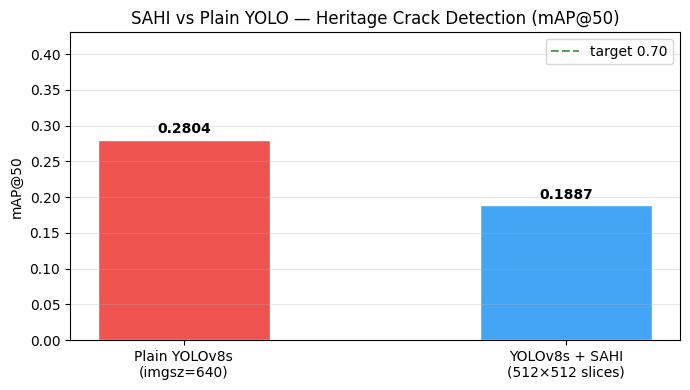

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))

labels_bar = ['Plain YOLOv8s\n(imgsz=640)', 'YOLOv8s + SAHI\n(512×512 slices)']
values     = [map50_plain, map50_sahi]
colors     = ['#EF5350', '#42A5F5']

bars = ax.bar(labels_bar, values, color=colors, edgecolor='white', width=0.45)
ax.axhline(0.70, color='green', linestyle='--', lw=1.5, alpha=0.7, label='target 0.70')
ax.set_ylabel('mAP@50')
ax.set_title('SAHI vs Plain YOLO — Heritage Crack Detection (mAP@50)')
ax.set_ylim(0, max(values) + 0.15)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
            f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR / 'sahi_map_comparison.png', dpi=150)
plt.show()

## 7. Save to Drive

In [14]:
DRIVE_SAHI = DRIVE_DIR / 'plots' / 'sahi_eval'
DRIVE_SAHI.mkdir(parents=True, exist_ok=True)

for f in sorted(OUT_DIR.glob('*.png')):
    shutil.copy2(f, DRIVE_SAHI / f.name)

summary = {
    'map50_plain_yolo': map50_plain,
    'map50_sahi': map50_sahi,
    'delta': map50_sahi - map50_plain,
    'slice_size': 'adaptive 256-512',
    'overlap': 0.2,
    'perform_standard_pred': True,
    'conf_threshold': 0.25,
    'test_images': len(test_samples),
}
(DRIVE_SAHI / 'sahi_summary.json').write_text(json.dumps(summary, indent=2))

print('Saved to Drive:')
for f in sorted(DRIVE_SAHI.iterdir()):
    print(f'  {f.name}')

print(f'\n=== Final ===')
print(f'Plain YOLO mAP@50 : {map50_plain:.4f}')
print(f'SAHI       mAP@50 : {map50_sahi:.4f}  ({map50_sahi - map50_plain:+.4f})')

Saved to Drive:
  sahi_map_comparison.png
  sahi_summary.json
  sahi_vs_yolo_qualitative.png

=== Final ===
Plain YOLO mAP@50 : 0.2804
SAHI       mAP@50 : 0.1887  (-0.0917)
